# Single Quantum Dot

This notebook is used to run numerical simulations of heterostructure hosting a sinlge quantum dot in 1D, 2D, and 3D. This will serve as a baseline case before scaling to larger architectures with multiple dots.

## 0. Setup

### - Imports

Import the necessary libraries and packagaes to run nextnano simulations.

In [6]:
import os
import re
import sys
import importlib.metadata
from pathlib import Path
import numpy as np
import nextnanopy as nn
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

print("Python:", sys.version)
print("CWD:", os.getcwd())
print("nextnanopy version:", importlib.metadata.version("nextnanopy"))

Python: 3.11.13 (main, Jun  5 2025, 08:14:07) [Clang 14.0.6 ]
CWD: /Users/robertjovanov/code/qpu-design-automation-toolkit/notebooks/experiments
nextnanopy version: 1.0.3


### - Input Config

Set here all the necessary configuration parameters for the simulation.

In [7]:
# path to simulation input file
INPUT_SINGLE_DOT_1D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit"
                    "/configs/nextnano_inputs/baseline_single_qd/1d"
                    "/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in")
print("INPUT_SINGLE_DOT_1D exists:", INPUT_SINGLE_DOT_1D.exists(), INPUT_SINGLE_DOT_1D)

INPUT_SINGLE_DOT_1D exists: True /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in


### - Helper functions

In [211]:
def read_nextnano_fld_rectilinear(path: Path):
    """
    Read nextnano AVS/Express .fld (ASCII, rectilinear).
    Returns: x_coords, y_coords, data (shape: [ny, nx] for scalar; [ny, nx, veclen] for vector)
    """
    path = Path(path)
    text = path.read_text(errors="ignore").splitlines()

    def get_int(key):
        m = re.search(rf"^{key}\s*=\s*(\d+)\s*$", "\n".join(text), flags=re.MULTILINE)
        if not m:
            raise ValueError(f"Could not find '{key} =' in header")
        return int(m.group(1))

    def get_str(key):
        m = re.search(rf"^{key}\s*=\s*(.+)\s*$", "\n".join(text), flags=re.MULTILINE)
        if not m:
            raise ValueError(f"Could not find '{key} =' in header")
        return m.group(1).strip()

    ndim = get_int("ndim")
    if ndim != 2:
        raise ValueError(f"Only ndim=2 supported here, got ndim={ndim}")

    nx = get_int("dim1")
    ny = get_int("dim2")
    veclen = get_int("veclen")
    field_type = get_str("field")
    if field_type != "rectilinear":
        raise ValueError(f"Only rectilinear supported, got field={field_type}")

    # parse skip lines for coords and data from the header lines like:
    # coord 1 ... skip=15
    # coord 2 ... skip=83
    # variable 1 ... skip=638
    header_blob = "\n".join(text)

    def get_skip(kind, idx):
        m = re.search(rf"^{kind}\s+{idx}\s+.*?\bskip=(\d+)\b", header_blob, flags=re.MULTILINE)
        if not m:
            raise ValueError(f"Could not find '{kind} {idx} ... skip=' in header")
        return int(m.group(1))

    skip_x = get_skip("coord", 1)
    skip_y = get_skip("coord", 2)
    skip_data = get_skip("variable", 1)

    # Helper to read a block of floats from lines starting at skip
    def read_floats_from_lines(start_line, count):
        vals = []
        i = start_line
        while i < len(text) and len(vals) < count:
            line = text[i].strip()
            if line and not line.startswith("#"):
                # some files may have multiple numbers per line
                vals.extend([float(v) for v in line.split()])
            i += 1
        if len(vals) < count:
            raise ValueError(f"Expected {count} floats from line {start_line}, got {len(vals)}")
        return np.array(vals[:count], dtype=float)

    x = read_floats_from_lines(skip_x, nx)
    y = read_floats_from_lines(skip_y, ny)

    data_count = nx * ny * veclen
    raw = read_floats_from_lines(skip_data, data_count)

    if veclen == 1:
        Z = raw.reshape((ny, nx))  # [y, x]
        return x, y, Z
    else:
        Z = raw.reshape((ny, nx, veclen))
        return x, y, Z

## 1. 1D Simulation

### 1.1 Global Equilibrium (Empty QW)

#### - Run simulation

Load the simulation input file.

In [8]:
# simulation input file
sd_1d = nn.InputFile(str(INPUT_SINGLE_DOT_1D))
print(sd_1d)

InputFile
fullpath: /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in
Input variables: 58 elements
	$strain = 1 # run strain model
	$poisson = 1 # solve the Poisson equation with bulk densities of states
	$quantum = 0 # solve the Schroedinger equation once
	$quantum_poisson = 1 # solve the Schroedinger equation self-consistently with the Poisson equation
	$effective_model = 0 # replace c-Ge cap with the alloy and effective charges, when set to 0, ideally one should have run $quantum_poisson = 1
	$n_c_Ge_QW_HH = 10
	$n_c_Ge_QW_LH = 10
	$n_Ge_under_oxide_HH = 10
	$n_Ge_under_oxide_LH = 10
	$temperature = 0.01 # (K)
	$V_PG = -3 # (V)
	$doping_cap = 0.0 # 5e18        # (cm^-3) doping in the modulation region of the cap layer
	$doping_buffer = 0.0 # 5e18        # (cm^-3) doping in the modulation region of the buffer layer
	$dop_energy = 0.02 # (eV) activation energy of the impurity
	$surface_char

Run the simulation.

In [9]:
sd_1d.execute()


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                                             
Th

{'process': <Popen: returncode: 0 args: '"/Applications/nextnano/2025_12_17/nextnano++/b...>,
 'outputdirectory': '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D',
 'filename': '2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D',
 'logfile': '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.log',
 'cmd': '"/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS_old" --license "/Applications/nextnano/2025_12_17/licenses/license.txt" --database "/Applications/nextnano/2025_12_17/nextnano++/database/database.nnp" --threads 0 --outputdirectory "/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D" --noautooutdir "/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in"',
 'wdir': '/Applications/nextnan

Set up access to output folder and output files from the simulation.

In [10]:
RUN_1D = Path(sd_1d.folder_output)

STRUCTURE_DIR_1D = RUN_1D / "Structure"
STRAIN_DIR_1D    = RUN_1D / "Strain"

# discover bias folders programmatically
BIAS_DIRS = sorted(p for p in RUN_1D.iterdir() if p.is_dir() and p.name.startswith("bias_"))

assert len(BIAS_DIRS) > 0, "No bias folders found"
BIAS0 = BIAS_DIRS[0]

print("Run root:      ", RUN_1D)
print("Structure dir:", STRUCTURE_DIR_1D)
print("Strain dir:   ", STRAIN_DIR_1D)
print("Bias folders: ", [p.name for p in BIAS_DIRS])

Run root:       /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D
Structure dir: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D/Structure
Strain dir:    /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D/Strain
Bias folders:  ['bias_00000']


#### - Band edges

In [11]:
bandedges_path = BIAS0 / "bandedges.dat"

df_be = pd.read_csv(
    bandedges_path,
    delim_whitespace=True,
    comment="#",
)

# print(df_be.columns)
# df_be.head()

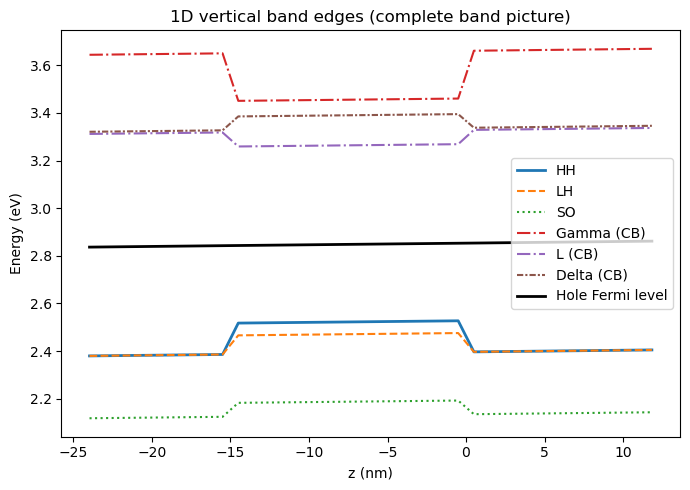

In [12]:
x = df_be["x[nm]"].iloc[194:250]

HH = df_be["HH[eV]"].iloc[194:250]
LH = df_be["LH[eV]"].iloc[194:250]
SO = df_be["SO[eV]"].iloc[194:250]

Gamma = df_be["Gamma[eV]"].iloc[194:250]
L1 = df_be["L_1[eV]"].iloc[194:250]
Delta1 = df_be["Delta_1[eV]"].iloc[194:250]

hF = df_be["hole_Fermi_level[eV]"].iloc[194:250]

plt.figure(figsize=(7, 5))

# Valence bands
plt.plot(x, HH, label="HH", linewidth=2)
plt.plot(x, LH, label="LH", linestyle="--")
plt.plot(x, SO, label="SO", linestyle=":")

# Conduction bands
plt.plot(x, Gamma, label="Gamma (CB)", linestyle="-.")
plt.plot(x, L1, label="L (CB)", linestyle="-.")

# Delta valley (CB)
plt.plot(x, Delta1, label="Delta (CB)", linestyle=(0, (3, 1, 1, 1)))  # dash-dot-dot

# Fermi level
plt.plot(x, hF, label="Hole Fermi level", color="black", linewidth=2)

plt.xlabel("z (nm)")
plt.ylabel("Energy (eV)")
plt.title("1D vertical band edges (complete band picture)")
plt.legend(loc="best")

plt.tight_layout()
plt.show()


Positive indications:
- Ordering of bands is as expected (conduction, fermi, valence), however the Fermi level is intentionally set at the middle of the bandgap
- Strain model works, there is a HH-LH split
- The SO band is much deeper and lowe in energy
- For Ge the L valley is relevant

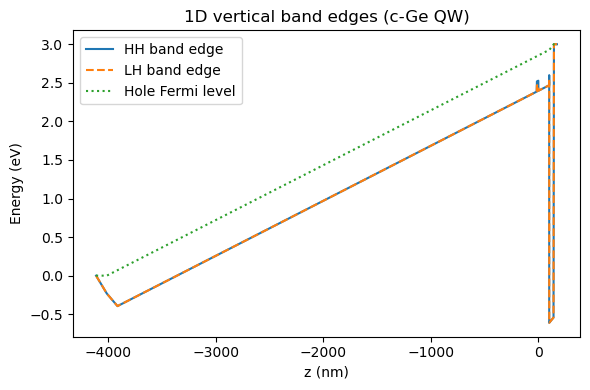

In [13]:
x = df_be["x[nm]"]
HH = df_be["HH[eV]"]
LH = df_be["LH[eV]"]
hF = df_be["hole_Fermi_level[eV]"]

plt.figure(figsize=(6, 4))

plt.plot(x, HH, label="HH band edge")
plt.plot(x, LH, label="LH band edge", linestyle="--")
plt.plot(x, hF, label="Hole Fermi level", linestyle=":")

plt.xlabel("z (nm)")
plt.ylabel("Energy (eV)")
plt.legend()
plt.title("1D vertical band edges (c-Ge QW)")

plt.tight_layout()
plt.show()

In [14]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_be["x[nm]"],
    y=df_be["HH[eV]"],
    name="HH band edge",
    mode="lines"
))

fig.add_trace(go.Scatter(
    x=df_be["x[nm]"],
    y=df_be["LH[eV]"],
    name="LH band edge",
    mode="lines"
    #line=dict(dash="dash")
))

fig.add_trace(go.Scatter(
    x=df_be["x[nm]"],
    y=df_be["hole_Fermi_level[eV]"],
    name="Hole Fermi level",
    mode="lines",
    line=dict(dash="dot")
))

fig.update_layout(
    title="1D vertical band edges",
    xaxis_title="z (nm)",
    yaxis_title="Energy (eV)",
    hovermode="x unified"
)

fig.show()


Positive indications:
- HH is higher in energy than LH 
- HH - LH split-off is present (stress tensor calculation probably works)
- skewed band edge (stress, gate potential, etc. can be causes for the band bending)
- square peak, indicates confinement already, the peak corresponds to the Germanium layer, no sharp cut-off at boundary z=-15 and z=0, doesn't span the whole quantum region

#### - Density

##### Total hole density

Index(['x[nm]', 'Hole_density[1e18_cm^-3]'], dtype='object')


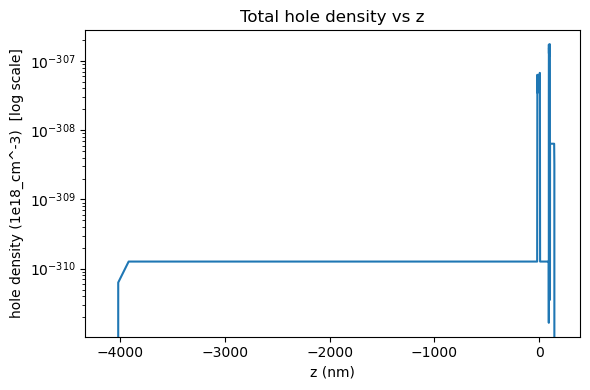

In [15]:
p = BIAS0 / "density_hole.dat"
assert p.exists(), p

df_h = pd.read_csv(p, delim_whitespace=True)
print(df_h.columns)

plt.figure(figsize=(6,4))
plt.semilogy(df_h.iloc[:,0], df_h.iloc[:,1])
plt.xlabel("z (nm)")
plt.ylabel("hole density (1e18_cm^-3)  [log scale]")
plt.title("Total hole density vs z")
plt.tight_layout()
plt.show()

In [16]:
p = BIAS0 / "density_hole.dat"
assert p.exists(), p

df_h = pd.read_csv(p, delim_whitespace=True)

z = df_h.iloc[:, 0]
p_h = df_h.iloc[:, 1]

fig = go.Figure()

# mark the Ge region in the heterostructure
fig.add_vline(x=-15, line_dash="dash")
fig.add_vline(x=0, line_dash="dash")

fig.add_trace(go.Scatter(x=z, y=p_h, mode="lines", name="hole density"))

fig.update_layout(
    title="Total hole density vs z",
    xaxis_title="z (nm)",
    yaxis_title="hole density(1e18_cm^-3)",
)

# log scale
fig.update_yaxes(type="log")

# zoom to the quantum well region
fig.update_xaxes(range=[-25, 10])

# interactive slider to quickly scan through the regions
fig.update_xaxes(rangeslider_visible=True)

fig.show()


Negative indication:
- There seems to be no accumulated charge density (essentially a numerical zero)

Positive indication:
- Is in agreement with the value in integrated_density_hole which is essentially a numerical zero

##### Quantum hole density in QW

Quantum HH density

Index(['x[nm]', 'Density[1e18_cm^-3]'], dtype='object')


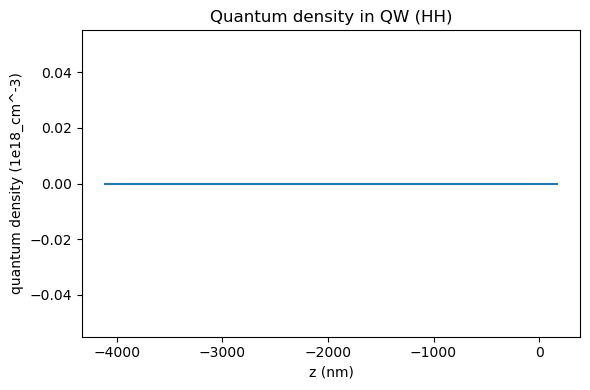

In [17]:
p_hh = BIAS0 / "Quantum" / "c-Ge_QW" / "HH" / "density.dat"
assert p_hh.exists(), p_hh

df_qhh = pd.read_csv(p_hh, delim_whitespace=True)
print(df_qhh.columns)

plt.figure(figsize=(6,4))
plt.plot(df_qhh.iloc[:,0], df_qhh.iloc[:,1])
plt.xlabel("z (nm)")
plt.ylabel("quantum density (1e18_cm^-3)")
plt.title("Quantum density in QW (HH)")
plt.tight_layout()
plt.show()

Quantum LH density

Index(['x[nm]', 'Density[1e18_cm^-3]'], dtype='object')


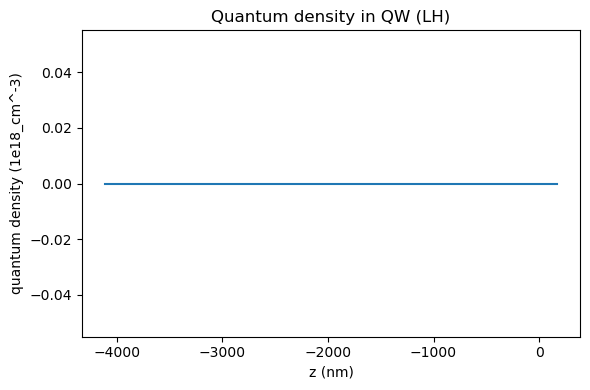

In [18]:
p_lh = BIAS0 / "Quantum" / "c-Ge_QW" / "LH" / "density.dat"
assert p_lh.exists(), p_lh

df_qlh = pd.read_csv(p_lh, delim_whitespace=True)
print(df_qlh.columns)

plt.figure(figsize=(6,4))
plt.plot(df_qlh.iloc[:,0], df_qlh.iloc[:,1])
plt.xlabel("z (nm)")
plt.ylabel("quantum density (1e18_cm^-3)")
plt.title("Quantum density in QW (LH)")
plt.tight_layout()
plt.show()

Quantum hole density

In [19]:
z_hh, rho_hh = df_qhh.iloc[:, 0], df_qhh.iloc[:, 1]
z_lh, rho_lh = df_qlh.iloc[:, 0], df_qlh.iloc[:, 1]

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=z_hh, y=rho_hh, mode="lines", name="Quantum HH density"))
fig.add_trace(go.Scatter(x=z_lh, y=rho_lh, mode="lines", name="Quantum LH density"))

fig.update_layout(
    title="Quantum density in c-Ge QW (HH vs LH)",
    xaxis_title="z (nm)",
    yaxis_title="Quantum density (1e18_cm^-3)",
    hovermode="x unified",
)

fig.update_yaxes(type="log")
fig.update_xaxes(range=[-25, 10])

# QW boundaries
fig.add_vline(x=-15, line_dash="dash")
fig.add_vline(x=0, line_dash="dash")

fig.show()


Negative indication:
- Even from the qunatum mechanical solutions there seems to be no accumulated charge density (essentially a numerical zero)

Positive indication:
- Is in agreement with the value in integrated_density_hole which is essentially a numerical zero, and they are all on the same order of magnitude (not sure if this is relevant)

#### - Quantum States

In [20]:
def plot_probabilities_file_one_axis(prob_file, *, title=None, show_rangeslider=True):
    """
    Plot nextnano probabilities_shift_k00000.dat on ONE set of axes:
      - x[nm] on the x-axis
      - E_1..E_5 and Psi^2_1..Psi^2_5 all as traces on the same y-axis

    Notes:
      - This mixes units (eV and nm^-1) on purpose, as requested.
      - Uses the full x-range automatically.
    """
    df = pd.read_csv(prob_file, delim_whitespace=True)

    # x column name varies; fall back to first column
    xcol = "x[nm]" if "x[nm]" in df.columns else df.columns[0]
    x = df[xcol]

    # take first 5 energy columns and first 5 Psi^2 columns (if present)
    E_cols = [c for c in df.columns if c.startswith("E_")][:5]
    P_cols = [c for c in df.columns if c.startswith("Psi^2_")][:5]
    if not E_cols and not P_cols:
        raise ValueError(f"No E_/Psi^2_ columns found in: {prob_file}")

    fig = go.Figure()

    # Energies
    for c in E_cols:
        fig.add_trace(go.Scatter(x=x, y=df[c], mode="lines", name=c))

    # Probabilities
    for c in P_cols:
        fig.add_trace(go.Scatter(x=x, y=df[c], mode="lines", name=c))

    fig.update_layout(
        title=title or f"probabilities file: {prob_file}",
        xaxis_title=xcol,
        yaxis_title="Mixed units (eV and nm⁻¹)",
        hovermode="x unified",
    )

    # fig.update_xaxes(rangeslider_visible=show_rangeslider)  # full range by default
    # fig.show()
    return fig


Bound states in HH (eigenenergies and eigenstates)

In [21]:
plot_probabilities_file_one_axis(
    BIAS0 / "Quantum" / "c-Ge_QW" / "HH" / "probabilities_shift_k00000.dat",
    title="Bound states (eigenvalues and eigenstates) of HH"
)


Bound states in LH (eigenenergies and eigenstates)

In [22]:
plot_probabilities_file_one_axis(
    BIAS0 / "Quantum" / "c-Ge_QW" / "LH" / "probabilities_shift_k00000.dat",
    title="Bound states (eigenvalues and eigenstates) of LH"
)


#### - Potential

In [25]:
df_pot = pd.read_csv(BIAS0 / "potential.dat", delim_whitespace=True)

x = df_pot["x[nm]"]
phi = df_pot["Potential[V]"]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=phi,
        mode="lines",
        name="Electrostatic potential",
        line=dict(width=3)
    )
)

fig.update_layout(
    title="Electrostatic Potential",
    xaxis_title="z (nm)",
    yaxis_title="Potential (V)",
    template="plotly_white",
    height=500
)

fig.show()


In [27]:
# ---- load data ----
df_pot = pd.read_csv(BIAS0 / "potential.dat", delim_whitespace=True)
x = df_pot["x[nm]"].to_numpy()
y = df_pot["Potential[V]"].to_numpy()

# ---- figurewidget ----
fig = go.FigureWidget(
    data=[go.Scatter(x=x, y=y, mode="lines", name="Potential")],
    layout=go.Layout(
        title="Electrostatic Potential",
        template="plotly_white",
        height=500,
        xaxis=dict(title="z (nm)"),
        yaxis=dict(title="Potential (V)"),
    ),
)

# ---- controls ----
xmin_w = widgets.FloatText(value=-20.0, description="x_min", step=1.0)
xmax_w = widgets.FloatText(value=5.0, description="x_max", step=1.0)
pad_w  = widgets.FloatSlider(value=0.05, min=0.0, max=0.3, step=0.01, description="y pad")
btn    = widgets.Button(description="Apply", button_style="primary")
msg    = widgets.HTML("")

def apply_range(_=None):
    xmin, xmax = float(xmin_w.value), float(xmax_w.value)
    if xmax <= xmin:
        msg.value = "<b style='color:#b00'>x_max must be > x_min</b>"
        return

    m = (x >= xmin) & (x <= xmax)
    if not np.any(m):
        msg.value = "<b style='color:#b00'>No data points in that interval.</b>"
        return

    y_win = y[m]
    ymin, ymax = float(np.nanmin(y_win)), float(np.nanmax(y_win))
    pad = (ymax - ymin) * float(pad_w.value) if ymax > ymin else 1e-9

    with fig.batch_update():
        fig.layout.xaxis.range = [xmin, xmax]
        fig.layout.yaxis.range = [ymin - pad, ymax + pad]

    msg.value = ""

btn.on_click(apply_range)

# initialize view
apply_range()

display(widgets.HBox([xmin_w, xmax_w, pad_w, btn]), msg, fig)


HTML(value='')

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Potential',
              'type': 'scatter',
              'uid': '7b8ad658-07d5-42cd-ab98-24bc5358f471',
              'x': {'bdata': ('AAAAAAATsMAAAAAAAF6vwABLOoxhl6' ... 'AAACBlQAAAAAAAYGVAAAAAAACgZUA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('pd5fBnIWAUBbaWgGchYBQMrKbOxrhQ' ... 'A9Ctfrv9ejcD0K1+u/16NwPQrX678='),
                    'dtype': 'f8'}}],
    'layout': {'height': 500,
               'template': '...',
               'title': {'text': 'Electrostatic Potential'},
               'xaxis': {'range': [-20.0, 5.0], 'title': {'text': 'z (nm)'}},
               'yaxis': {'range': [-0.730916455117171, -0.7117978569785091], 'title': {'text': 'Potential (V)'}}}
})

KeyError: 'uid'

#### - Electric Field

In [28]:
df_E = pd.read_csv(BIAS0 / "electric_field.dat", delim_whitespace=True)

x = df_E["x[nm]"]
E = df_E["E[kV/cm]"]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=E,
        mode="lines",
        name="Electric field",
        line=dict(width=3)
    )
)

fig.update_layout(
    title="Electric Field",
    xaxis_title="z (nm)",
    yaxis_title="Electric Field (kV/cm)",
    template="plotly_white",
    height=500
)

fig.show()


### 1.2 Effective Surface Charge Model

#### - Run simulation

First let's turn on the effective model which adds a sheet charge density of 9.93016e+11(cm^-2) (estimated value) in the Ge cap layer.

In [142]:
# turn on effective model
sd_1d.set_variable('effective_model', value=1)
sd_1d.save('/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_effective_model_1D.in')

# Run simulation
sd_1d.execute()

print("Output folder:", sd_1d.folder_output)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Single_Quantum_Dot_effective_model_1D_1 --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_effective_model_1D_1.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                                             
The 

In [143]:
RUN = Path(sd_1d.folder_output)
BIAS0 = RUN / "bias_00000"

# Toggle zoom on/off here
ZOOM_QW = True
QW_XRANGE = [-20, 5]   # quantum region

def read_nn_dat(path: Path):
    return pd.read_csv(path, delim_whitespace=True, comment="#")

def plot_lines(df, xcol, ycols, title, y_label="", zoom=ZOOM_QW):
    fig = go.Figure()
    x = df[xcol]

    for c in ycols:
        if c in df.columns:
            fig.add_trace(go.Scatter(x=x, y=df[c], mode="lines", name=c))
        else:
            print(f"Column not found: {c}")

    fig.update_layout(
        title=title,
        xaxis_title="z (nm)",
        yaxis_title=y_label,
        template="plotly_white",
        height=520
    )

    if zoom:
        fig.update_xaxes(range=QW_XRANGE)

    fig.show()


#### - Band edges

In [144]:
df_be = read_nn_dat(BIAS0 / "bandedges.dat")

plot_lines(
    df_be,
    xcol="x[nm]",
    ycols=[
        "HH[eV]", "LH[eV]", "SO[eV]",
        "Gamma[eV]",
        "Delta_1[eV]", "Delta_2[eV]", "Delta_3[eV]",
        "L_1[eV]", "L_2[eV]", "L_3[eV]", "L_4[eV]",
        "electron_Fermi_level[eV]", "hole_Fermi_level[eV]"
    ],
    title="Band edges + Fermi levels",
    y_label="Energy (eV)"
)


#### - Potential

In [145]:
df_pot = read_nn_dat(BIAS0 / "potential.dat")

plot_lines(
    df_pot,
    xcol="x[nm]",
    ycols=["Potential[V]"],
    title="Electrostatic potential",
    y_label="Potential (V)"
)


#### - Electric Field

In [146]:
df_ef = read_nn_dat(BIAS0 / "electric_field.dat")

plot_lines(
    df_ef,
    xcol="x[nm]",
    ycols=["E[kV/cm]"],
    title="Electric field",
    y_label="E (kV/cm)"
)


#### - Density

In [147]:
df_e = read_nn_dat(BIAS0 / "density_electron.dat")

electron_col = next(c for c in df_e.columns if "Electron_density" in c)

plot_lines(
    df_e,
    xcol="x[nm]",
    ycols=[electron_col],
    title="Electron density",
    y_label=electron_col
)

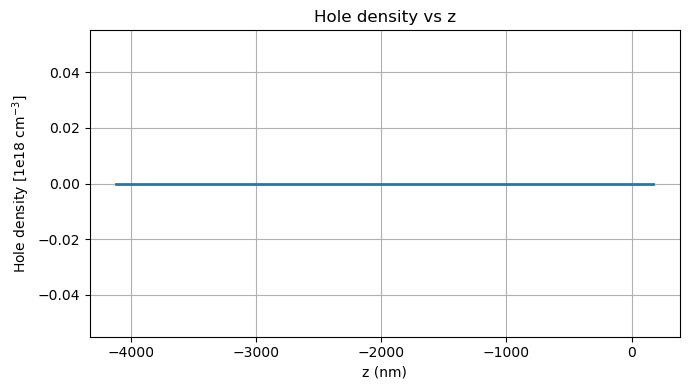

In [148]:
# Read file
df_h = pd.read_csv(BIAS0 / "density_hole.dat", delim_whitespace=True)

# Extract columns
x = df_h["x[nm]"]
y = df_h["Hole_density[1e18_cm^-3]"]

# Plot
plt.figure(figsize=(7,4))
plt.plot(x, y, linewidth=2)
plt.xlabel("z (nm)")
plt.ylabel("Hole density [1e18 cm$^{-3}$]")
plt.title("Hole density vs z")
plt.grid(True)
plt.tight_layout()
plt.show()


#### - Quantum States

In [149]:
plot_probabilities_file_one_axis(
    BIAS0 / "Quantum" / "c-Ge_QW" / "HH" / "probabilities_shift_k00000.dat",
    title="Bound states (eigenvalues and eigenstates) of HH"
)

In [150]:
plot_probabilities_file_one_axis(
    BIAS0 / "Quantum" / "c-Ge_QW" / "LH" / "probabilities_shift_k00000.dat",
    title="Bound states (eigenvalues and eigenstates) of LH"
)

### 1.3 Gate Bias Sweep

In [154]:
# Base input file
inp_path = "/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_effective_model_1D_1.in"

# Choose sweep points
VPG = np.linspace(-0.5, -4.0, 8).tolist()

sweep_variables = {
    "V_PG": VPG
}

VPG_sweep = nn.Sweep(sweep_variables, inp_path)
print(VPG_sweep)


Sweep
fullpath: /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_effective_model_1D_1.in
Input variables: 0 elements


In [155]:
# generate the sweep input files
VPG_sweep.save_sweep(delete_old_files=True)
VPG_sweep.input_files

[InputFile
 fullpath: /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_effective_model_1D_1__V_PG_-0.5_.in
 Input variables: 58 elements
 	$strain = 1 # run strain model
 	$poisson = 0 # solve the Poisson equation with bulk densities of states
 	$quantum = 0 # solve the Schroedinger equation once
 	$quantum_poisson = 1 # solve the Schroedinger equation self-consistently with the Poisson equation
 	$effective_model = 1 # replace c-Ge cap with the alloy and effective charges, when set to 0, ideally one should have run $quantum_poisson = 1
 	$n_c_Ge_QW_HH = 10
 	$n_c_Ge_QW_LH = 10
 	$n_Ge_under_oxide_HH = 10
 	$n_Ge_under_oxide_LH = 10
 	$temperature = 0.01 # (K)
 	$V_PG = -0.5 # THIS VARIABLE IS UNDER SWEEP
 	$doping_cap = 0.0 # 5e18        # (cm^-3) doping in the modulation region of the cap layer
 	$doping_buffer = 0.0 # 5e18        # (cm^-3) doping in the modulation region of the buffer layer
 	$dop_energy = 0.02 

In [156]:
# run the sweep
VPG_sweep.execute_sweep(
    delete_input_files=False,
    overwrite=True,
    show_log=True,
    convergenceCheck=True,
    parallel_limit=1
)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Single_Quantum_Dot_effective_model_1D_1_sweep__V_PG/Single_Quantum_Dot_effective_model_1D_1__V_PG_-0.5_ --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_effective_model_1D_1__V_PG_-0.5_.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
      

Plot: Integrated hole sheet density in the QW vs PG bias

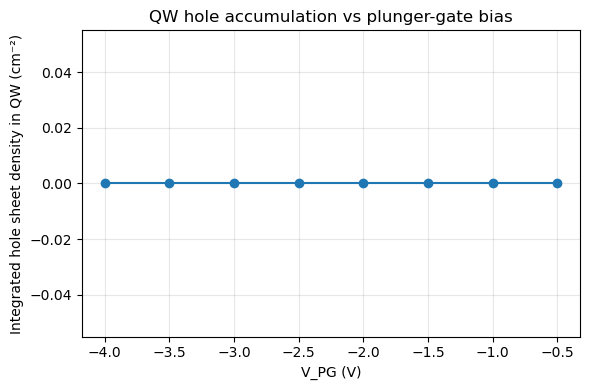

,V_PG [V],p_QW_sheet [cm^-2]
7,-4.0,9.160678e-296
6,-3.5,9.158986e-296
5,-3.0,9.157029e-296
4,-2.5,9.154969e-296
3,-2.0,9.153007e-296
2,-1.5,9.151467e-296
1,-1.0,9.150825e-296
0,-0.5,9.151358e-296


In [164]:
SWEEP_ROOT = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Single_Quantum_Dot_effective_model_1D_1_sweep__V_PG")

# collect (V_PG, p_sheet_QW)
rows = []

for run_dir in sorted([p for p in SWEEP_ROOT.iterdir() if p.is_dir() and "__V_PG_" in p.name]):
    m = re.search(r"__V_PG_([-0-9.]+)_", run_dir.name)
    if not m:
        continue
    VPG = float(m.group(1))

    f = run_dir / "integrated_density_hole.dat"
    if not f.exists():
        print("Missing:", f)
        continue

    df = pd.read_csv(f, delim_whitespace=True)
    # pick the integrated region column (e.g. region_3[carriers/cm^2])
    region_cols = [c for c in df.columns if c.startswith("region_") and "carriers/cm^2" in c]
    if not region_cols:
        raise ValueError(f"No region_* carriers/cm^2 column found in {f}. Columns: {list(df.columns)}")
    col = region_cols[0]  # effective_model=1 -> should be just the QW region

    p_sheet = float(df[col].iloc[0])  # carriers/cm^2
    rows.append((VPG, p_sheet))

# dataframe sorted by voltage
sweep = pd.DataFrame(rows, columns=["V_PG [V]", "p_QW_sheet [cm^-2]"]).sort_values("V_PG [V]")

plt.figure(figsize=(6,4))
plt.plot(sweep["V_PG [V]"], sweep["p_QW_sheet [cm^-2]"], marker="o")
plt.xlabel("V_PG (V)")
plt.ylabel("Integrated hole sheet density in QW (cm⁻²)")
plt.title("QW hole accumulation vs plunger-gate bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(sweep)


Plot: electrons (and net “sum”) vs V_PG

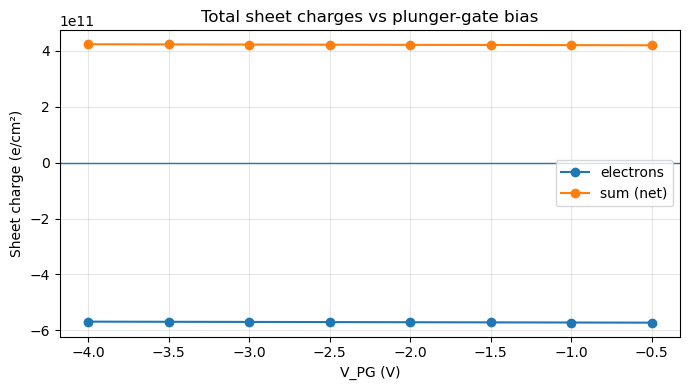

,V_PG [V],electrons [e/cm^2],holes [e/cm^2],fixed charges [e/cm^2],sum [e/cm^2]
7,-4.0,-5.691706e+11,2.175956e-295,9.930160e+11,4.238454e+11
6,-3.5,-5.696925e+11,2.175956e-295,9.930160e+11,4.233235e+11
5,-3.0,-5.702145e+11,2.175956e-295,9.930160e+11,4.228015e+11
4,-2.5,-5.707365e+11,2.175956e-295,9.930160e+11,4.222795e+11
3,-2.0,-5.712585e+11,2.175956e-295,9.930160e+11,4.217575e+11
2,-1.5,-5.717805e+11,2.175956e-295,9.930160e+11,4.212355e+11
1,-1.0,-5.723025e+11,2.175956e-295,9.930160e+11,4.207135e+11
0,-0.5,-5.728246e+11,2.175956e-295,9.930160e+11,4.201914e+11


In [165]:
def parse_total_charges(txt_path: Path) -> dict:
    d = {}
    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or ":" not in line:
                continue
            key, rest = line.split(":", 1)
            key = key.strip()
            # grab first float in the remainder
            m = re.search(r"([-+]?\d+\.\d+e[+-]?\d+)", rest)
            if m:
                d[key] = float(m.group(1))
    return d

rows = []
for run_dir in sorted([p for p in SWEEP_ROOT.iterdir() if p.is_dir() and "__V_PG_" in p.name]):
    m = re.search(r"__V_PG_([-0-9.]+)_", run_dir.name)
    if not m:
        continue
    VPG = float(m.group(1))
    f = run_dir / "bias_00000" / "total_charges.txt"
    if not f.exists():
        print("Missing:", f)
        continue
    d = parse_total_charges(f)
    rows.append({
        "V_PG [V]": VPG,
        "electrons [e/cm^2]": d.get("electrons", float("nan")),
        "holes [e/cm^2]": d.get("holes", float("nan")),
        "fixed charges [e/cm^2]": d.get("fixed charges", float("nan")),
        "sum [e/cm^2]": d.get("sum", float("nan")),
    })

df = pd.DataFrame(rows).sort_values("V_PG [V]")

plt.figure(figsize=(7,4))
plt.plot(df["V_PG [V]"], df["electrons [e/cm^2]"], marker="o", label="electrons")
plt.plot(df["V_PG [V]"], df["sum [e/cm^2]"], marker="o", label="sum (net)")
plt.axhline(0, linewidth=1)
plt.xlabel("V_PG (V)")
plt.ylabel("Sheet charge (e/cm²)")
plt.title("Total sheet charges vs plunger-gate bias")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(df)


Plot: HH/LH band edge vs Fermi level accross different voltages

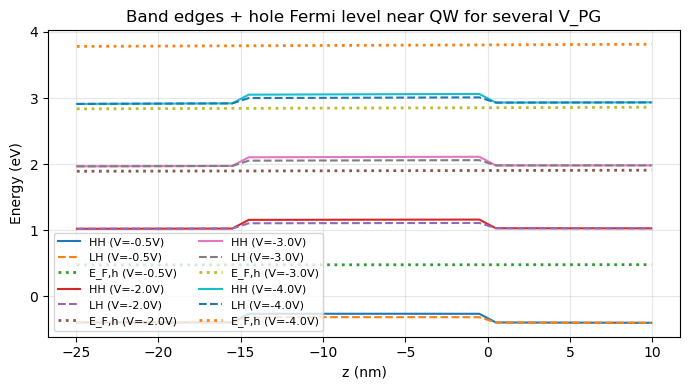

In [166]:
def read_nn_dat(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, delim_whitespace=True, comment="#")

# choose a few voltages to overlay
V_SELECT = [-0.5, -2.0, -3.0, -4.0]

plt.figure(figsize=(7,4))

for V in V_SELECT:
    # find the run folder matching this V
    run_dir = next(
        p for p in SWEEP_ROOT.iterdir()
        if p.is_dir() and f"__V_PG_{V}_" in p.name
    )
    df = read_nn_dat(run_dir / "bias_00000" / "bandedges.dat")

    x = df["x[nm]"]
    HH = df["HH[eV]"]
    LH = df["LH[eV]"]
    hF = df["hole_Fermi_level[eV]"]

    # zoom window: QW ~ [-20, 5] nm in your coordinate convention
    mask = (x >= -25) & (x <= 10)

    plt.plot(x[mask], HH[mask], label=f"HH (V={V}V)")
    plt.plot(x[mask], LH[mask], linestyle="--", label=f"LH (V={V}V)")
    plt.plot(x[mask], hF[mask], linestyle=":", linewidth=2, label=f"E_F,h (V={V}V)")

plt.xlabel("z (nm)")
plt.ylabel("Energy (eV)")
plt.title("Band edges + hole Fermi level near QW for several V_PG")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [168]:
def read_nn_dat(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, delim_whitespace=True, comment="#")

# voltages to overlay (edit as you like)
V_SELECT = [-0.5, -2.0, -3.0, -4.0]

# zoom window around QW (edit as you like)
XMIN, XMAX = -25, 10

fig = go.Figure()

for V in V_SELECT:
    run_dir = next(
        p for p in SWEEP_ROOT.iterdir()
        if p.is_dir() and f"__V_PG_{V}_" in p.name
    )
    df = read_nn_dat(run_dir / "bias_00000" / "bandedges.dat")

    x = df["x[nm]"]
    mask = (x >= XMIN) & (x <= XMAX)

    fig.add_trace(go.Scatter(
        x=x[mask], y=df["HH[eV]"][mask],
        mode="lines",
        name=f"HH (V_PG={V} V)"
    ))
    fig.add_trace(go.Scatter(
        x=x[mask], y=df["LH[eV]"][mask],
        mode="lines",
        name=f"LH (V_PG={V} V)",
        line=dict(dash="dash")
    ))
    fig.add_trace(go.Scatter(
        x=x[mask], y=df["hole_Fermi_level[eV]"][mask],
        mode="lines",
        name=f"E_F,h (V_PG={V} V)",
        line=dict(dash="dot", width=3)
    ))

fig.update_layout(
    title="Band edges + hole Fermi level near QW (toggle traces via legend)",
    xaxis_title="z (nm)",
    yaxis_title="Energy (eV)",
    template="plotly_white",
    height=550,
    legend=dict(itemclick="toggle", itemdoubleclick="toggleothers"),
)

fig.show()


,V_PG,dHH_min_eV,z_at_dHH_min_nm,dLH_min_eV,z_at_dLH_min_nm
0,-4.0,0.740623,-14.5,0.792088,-14.5
1,-3.5,0.740628,-14.5,0.792093,-14.5
2,-3.0,0.740633,-14.5,0.792097,-14.5
3,-2.5,0.740638,-14.5,0.792102,-14.5
4,-2.0,0.740642,-14.5,0.792107,-14.5
5,-1.5,0.740647,-14.5,0.792112,-14.5
6,-1.0,0.740652,-14.5,0.792116,-14.5
7,-0.5,0.740656,-14.5,0.792121,-14.5


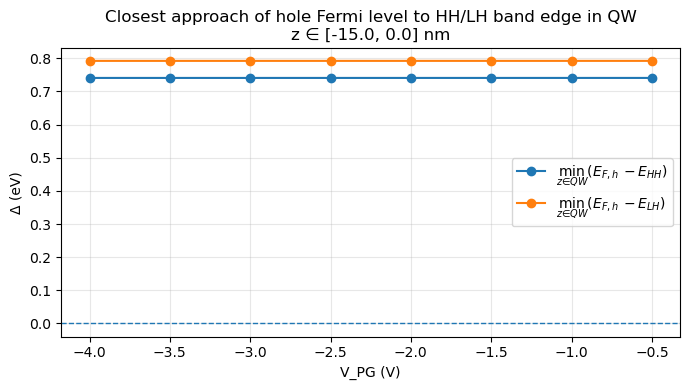

In [169]:
QW_WINDOW_NM = (-15.0, 0.0)            # the Ge QW in your origin convention

def _parse_vpg_from_folder(name: str) -> float:
    # expects folder names like: Single_Quantum_Dot_effective_model_1D_1__V_PG_-3.0_
    m = re.search(r"__V_PG_([-\d\.]+)_", name)
    if not m:
        raise ValueError(f"Could not parse V_PG from folder name: {name}")
    return float(m.group(1))

def _read_nn_dat(path: Path) -> pd.DataFrame:
    # nextnano .dat are whitespace-delimited with a header row
    return pd.read_csv(path, delim_whitespace=True, comment="#")

rows = []
run_dirs = sorted([p for p in SWEEP_ROOT.iterdir() if p.is_dir() and "__V_PG_" in p.name], key=lambda p: _parse_vpg_from_folder(p.name))

for run_dir in run_dirs:
    vpg = _parse_vpg_from_folder(run_dir.name)
    be_path = run_dir / "bias_00000" / "bandedges.dat"
    df = _read_nn_dat(be_path)

    x = df["x[nm]"].to_numpy()
    mask = (x >= QW_WINDOW_NM[0]) & (x <= QW_WINDOW_NM[1])

    # columns (as in your file)
    HH = df["HH[eV]"].to_numpy()[mask]
    LH = df["LH[eV]"].to_numpy()[mask]
    EFh = df["hole_Fermi_level[eV]"].to_numpy()[mask]

    # metrics: min_z (EFh - bandedge) inside QW
    dHH_min = np.min(EFh - HH)
    dLH_min = np.min(EFh - LH)

    # also useful: where it happens (z position)
    zHH = x[mask][np.argmin(EFh - HH)]
    zLH = x[mask][np.argmin(EFh - LH)]

    rows.append(
        dict(
            V_PG=vpg,
            dHH_min_eV=dHH_min,
            z_at_dHH_min_nm=zHH,
            dLH_min_eV=dLH_min,
            z_at_dLH_min_nm=zLH,
        )
    )

df_gap = pd.DataFrame(rows).sort_values("V_PG").reset_index(drop=True)
display(df_gap)

plt.figure(figsize=(7,4))
plt.plot(df_gap["V_PG"], df_gap["dHH_min_eV"], marker="o", label=r"$\min_{z\in QW}(E_{F,h}-E_{HH})$")
plt.plot(df_gap["V_PG"], df_gap["dLH_min_eV"], marker="o", label=r"$\min_{z\in QW}(E_{F,h}-E_{LH})$")
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("V_PG (V)")
plt.ylabel("Δ (eV)")
plt.title(f"Closest approach of hole Fermi level to HH/LH band edge in QW\nz ∈ [{QW_WINDOW_NM[0]}, {QW_WINDOW_NM[1]}] nm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


,V_PG,dphi_QW_V,phi_mean_QW_V,E_mean_QW_kVcm,E_ptp_QW_kVcm
0,-4.0,-0.011132,-1.254753,7.421272,4.385391
1,-3.5,-0.009428,-0.780072,6.285033,4.385996
2,-3.0,-0.007723,-0.305391,5.148788,4.386601
3,-2.5,-0.006019,0.169290,4.012533,4.387207
4,-2.0,-0.004314,0.643971,2.876267,4.387813
5,-1.5,-0.002610,1.118652,1.739994,4.388420
6,-1.0,-0.000906,1.593333,0.603714,4.389027
7,-0.5,0.000799,2.068014,-0.532571,4.389635


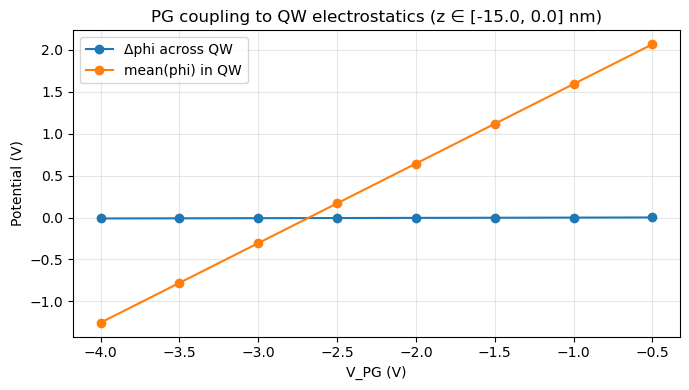

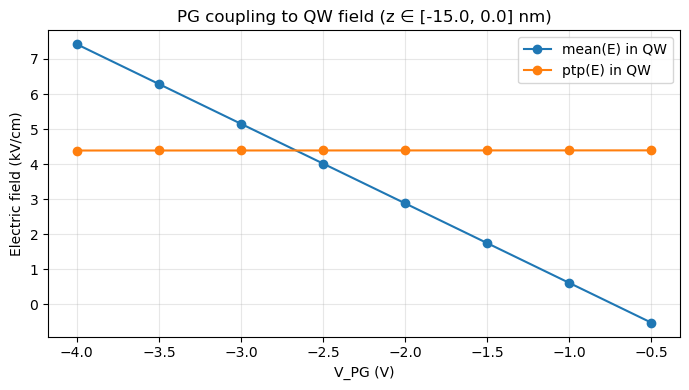

In [174]:
QW_WINDOW_NM = (-15.0, 0.0)

def _parse_vpg_from_folder(name: str) -> float:
    m = re.search(r"__V_PG_([-\d\.]+)_", name)
    if not m:
        raise ValueError(f"Could not parse V_PG from folder name: {name}")
    return float(m.group(1))

def _read_nn_dat(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, delim_whitespace=True, comment="#")

rows = []
run_dirs = sorted(
    [p for p in SWEEP_ROOT.iterdir() if p.is_dir() and "__V_PG_" in p.name],
    key=lambda p: _parse_vpg_from_folder(p.name)
)

for run_dir in run_dirs:
    vpg = _parse_vpg_from_folder(run_dir.name)

    pot_path = run_dir / "bias_00000" / "potential.dat"
    ef_path  = run_dir / "bias_00000" / "electric_field.dat"

    # --- Potential on its own grid ---
    dfp = _read_nn_dat(pot_path)
    z_p = dfp["x[nm]"].to_numpy()
    phi = dfp["Potential[V]"].to_numpy()
    mask_p = (z_p >= QW_WINDOW_NM[0]) & (z_p <= QW_WINDOW_NM[1])

    z_qw = z_p[mask_p]
    phi_qw = phi[mask_p]

    # robust "edges" even if ordering flips
    i_lo = np.argmin(z_qw)
    i_hi = np.argmax(z_qw)
    dphi_qw = float(phi_qw[i_hi] - phi_qw[i_lo])
    phi_mean = float(np.mean(phi_qw))

    # --- Electric field on its own grid ---
    dfe = _read_nn_dat(ef_path)
    z_e = dfe["x[nm]"].to_numpy()
    E   = dfe["E[kV/cm]"].to_numpy()
    mask_e = (z_e >= QW_WINDOW_NM[0]) & (z_e <= QW_WINDOW_NM[1])

    E_qw = E[mask_e]
    E_mean = float(np.mean(E_qw)) if E_qw.size else np.nan
    E_ptp  = float(np.ptp(E_qw))  if E_qw.size else np.nan

    rows.append(dict(
        V_PG=vpg,
        dphi_QW_V=dphi_qw,
        phi_mean_QW_V=phi_mean,
        E_mean_QW_kVcm=E_mean,
        E_ptp_QW_kVcm=E_ptp
    ))

df_qw = pd.DataFrame(rows).sort_values("V_PG").reset_index(drop=True)
display(df_qw)

plt.figure(figsize=(7,4))
plt.plot(df_qw["V_PG"], df_qw["dphi_QW_V"], marker="o", label="Δphi across QW")
plt.plot(df_qw["V_PG"], df_qw["phi_mean_QW_V"], marker="o", label="mean(phi) in QW")
plt.xlabel("V_PG (V)")
plt.ylabel("Potential (V)")
plt.title(f"PG coupling to QW electrostatics (z ∈ [{QW_WINDOW_NM[0]}, {QW_WINDOW_NM[1]}] nm)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(df_qw["V_PG"], df_qw["E_mean_QW_kVcm"], marker="o", label="mean(E) in QW")
plt.plot(df_qw["V_PG"], df_qw["E_ptp_QW_kVcm"], marker="o", label="ptp(E) in QW")
plt.xlabel("V_PG (V)")
plt.ylabel("Electric field (kV/cm)")
plt.title(f"PG coupling to QW field (z ∈ [{QW_WINDOW_NM[0]}, {QW_WINDOW_NM[1]}] nm)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [175]:
# Mean-subtracted potential in the QW window for two sweep points
# (tests: "shape unchanged, offset changed")

QW_MIN, QW_MAX = -15.0, 0.0

# pick two sweep folders (adjust if you want different points)
cases = [
    ("V_PG=-0.5 V", SWEEP_ROOT / "Single_Quantum_Dot_effective_model_1D_1__V_PG_-0.5_" / "bias_00000"),
    ("V_PG=-4.0 V", SWEEP_ROOT / "Single_Quantum_Dot_effective_model_1D_1__V_PG_-4.0_" / "bias_00000"),
]

def read_nn_dat(path: Path) -> pd.DataFrame:
    # robust for nextnano .dat files with whitespace separators
    return pd.read_csv(path, delim_whitespace=True, comment="#")

fig = go.Figure()

for label, bias_dir in cases:
    df = read_nn_dat(bias_dir / "potential.dat")
    z = df["x[nm]"].to_numpy()
    phi = df["Potential[V]"].to_numpy()

    mask_qw = (z >= QW_MIN) & (z <= QW_MAX)
    phi_mean_qw = float(np.mean(phi[mask_qw]))
    phi_tilde = phi - phi_mean_qw  # mean-subtracted using QW mean

    # plot only a slightly wider window for clarity (change if you want)
    mask_plot = (z >= QW_MIN - 10) & (z <= QW_MAX + 10)

    fig.add_trace(
        go.Scatter(
            x=z[mask_plot],
            y=phi_tilde[mask_plot],
            mode="lines",
            name=f"{label}  (φ - ⟨φ⟩_QW)",
            line=dict(width=3),
        )
    )

fig.update_layout(
    title="Mean-subtracted electrostatic potential near QW (tests rigid shift vs shape change)",
    xaxis_title="z (nm)",
    yaxis_title="φ(z) - ⟨φ⟩_QW  (V)",
    template="plotly_white",
    height=520,
)

# show QW window
fig.add_vrect(x0=QW_MIN, x1=QW_MAX, fillcolor="gray", opacity=0.12, line_width=0)

fig.show()


In [4]:
# --- HH bandedge + eigenenergies + |psi|^2 (AS-IS, no rescaling) ---

def _read_nn_dat(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, delim_whitespace=True, comment="#")

def plot_hh_bandedge_and_states_raw(
    bandedges_path: Path,
    probabilities_path: Path,
    n_states: int = 5,
    xlim: tuple[float, float] | None = None,
    hh_col: str = "HH[eV]",
    x_col_be: str = "x[nm]",
    x_col_prob: str = "x[nm]",
    title: str = "HH band edge + eigenenergies + |ψ|²",
):
    """
    Plots everything raw (no scaling):
      - HH band edge (eV)
      - E_n (eV)
      - Psi^2_n (nm^-1)
    Note: Psi^2 has different units/magnitude than energies, so it will likely
    compress the energy traces unless you hide Psi^2 or use the right y-axis.
    """
    df_be = _read_nn_dat(Path(bandedges_path))
    df_p  = _read_nn_dat(Path(probabilities_path))

    x_be = df_be[x_col_be]
    hh   = df_be[hh_col]

    x_p = df_p[x_col_prob]

    e_cols   = [f"E_{i}[eV]" for i in range(1, n_states + 1)]
    psi_cols = [f"Psi^2_{i}[nm^-1]" for i in range(1, n_states + 1)]

    missing = [c for c in (e_cols + psi_cols) if c not in df_p.columns]
    if missing:
        raise ValueError(f"Missing columns in probabilities file: {missing}\n"
                         f"Available columns: {list(df_p.columns)}")

    fig = go.Figure()

    fig.add_trace(go.Scatter(x=x_be, y=hh, mode="lines", name="HH band edge", line=dict(width=3)))

    for i in range(1, n_states + 1):
        fig.add_trace(go.Scatter(
            x=x_p, y=df_p[f"E_{i}[eV]"],
            mode="lines", name=f"E{i}",
            line=dict(width=2, dash="dot"),
        ))
        fig.add_trace(go.Scatter(
            x=x_p, y=df_p[f"Psi^2_{i}[nm^-1]"],
            mode="lines", name=f"Psi^2_{i}",
            line=dict(width=2),
        ))

    fig.update_layout(
        title=title,
        xaxis_title="z (nm)",
        yaxis_title="Energy (eV) / Psi^2 (nm^-1)",
        template="plotly_white",
        height=600,
        legend=dict(itemclick="toggle", itemdoubleclick="toggleothers"),
    )

    if xlim is not None:
        fig.update_xaxes(range=[xlim[0], xlim[1]])

    fig.show()


In [5]:
# Example:
base = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D") / "bias_00000"
plot_hh_bandedge_and_states_raw(
    bandedges_path=base / "bandedges.dat",
    probabilities_path=base / "Quantum" / "c-Ge_QW" / "HH" / "probabilities_shift_k00000.dat",
    n_states=2,
    xlim=(-25, 10),
)

### 1.4 Self-consistency check

In [30]:
sd_1d.folder_input

'/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d'

Run quantum_poisson with iterations=1.

In [31]:
INP_ORIG = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in")

text = INP_ORIG.read_text()

# Replace quantum_poisson{} block with quantum_poisson{ iterations = 1 }
# Works if your run block contains "quantum_poisson{}" exactly.
text_it1 = re.sub(
    r"quantum_poisson\s*\{\s*\}",
    "quantum_poisson{\n        iterations = 1\n    }",
    text
)

# If it already has quantum_poisson{...}, overwrite the iterations line (or insert it)
if text_it1 == text:
    # overwrite existing iterations if present, else insert after quantum_poisson{
    if re.search(r"quantum_poisson\s*\{[^}]*iterations\s*=", text, flags=re.DOTALL):
        text_it1 = re.sub(
            r"(quantum_poisson\s*\{[^}]*?iterations\s*=\s*)\d+",
            r"\g<1>1",
            text,
            flags=re.DOTALL
        )
    else:
        text_it1 = re.sub(
            r"quantum_poisson\s*\{",
            "quantum_poisson{\n        iterations = 1",
            text
        )

INP_IT1 = INP_ORIG.with_name(INP_ORIG.stem + "_it1.in")
INP_IT1.write_text(text_it1)

print("Wrote:", INP_IT1)

sd_it1 = nn.InputFile(str(INP_IT1))
sd_it1.execute()

print("Output folder (it=1):", sd_it1.folder_output)

Wrote: /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_it1.in

PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_it1 --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_it1.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF T

Run Poisson and quantum separately (no self-consistency)

In [35]:
INP_ORIG = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in")
sd_pq = nn.InputFile(str(INP_ORIG))

# solver switches
sd_pq.set_variable("poisson", 1)
sd_pq.set_variable("quantum", 1)
sd_pq.set_variable("quantum_poisson", 0)

# save as new input file
INP_PQ = INP_ORIG.with_name(INP_ORIG.stem + "_poisson_quantum.in")
sd_pq.save(str(INP_PQ))

print("Wrote:", INP_PQ)

Wrote: /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_poisson_quantum.in


In [37]:
sd_pq_run = nn.InputFile("/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_poisson_quantum_0.in")
sd_pq_run.execute()

print("Output folder:", sd_pq_run.folder_output)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_poisson_quantum_0 --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_poisson_quantum_0.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                            

Plot 1: Potential

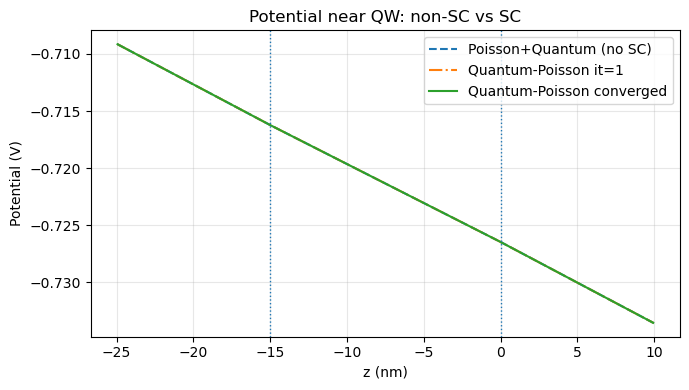

In [39]:
RUN_FULL = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D")
RUN_IT1  = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_it1")
RUN_PQ   = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_poisson_quantum_0")

BIAS = "bias_00000"
XMIN, XMAX = -25, 10  # zoom around QW

def read_potential(run_root: Path) -> pd.DataFrame:
    f = run_root / BIAS / "potential.dat"
    return pd.read_csv(f, delim_whitespace=True)

df_full = read_potential(RUN_FULL)
df_it1  = read_potential(RUN_IT1)
df_pq   = read_potential(RUN_PQ)

plt.figure(figsize=(7,4))

for df, label, ls in [
    (df_pq,  "Poisson+Quantum (no SC)", "--"),
    (df_it1, "Quantum-Poisson it=1",    "-."),
    (df_full,"Quantum-Poisson converged", "-"),
]:
    m = (df["x[nm]"] >= XMIN) & (df["x[nm]"] <= XMAX)
    plt.plot(df.loc[m, "x[nm]"], df.loc[m, "Potential[V]"], label=label, linestyle=ls)

plt.axvline(-15, linestyle=":", linewidth=1)
plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("z (nm)")
plt.ylabel("Potential (V)")
plt.title("Potential near QW: non-SC vs SC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Plot 2: Electric field

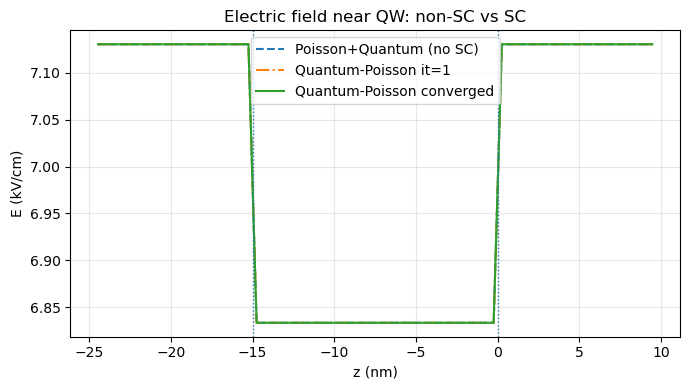

In [40]:
def read_efield(run_root: Path) -> pd.DataFrame:
    f = run_root / BIAS / "electric_field.dat"
    return pd.read_csv(f, delim_whitespace=True)

dfE_full = read_efield(RUN_FULL)
dfE_it1  = read_efield(RUN_IT1)
dfE_pq   = read_efield(RUN_PQ)

plt.figure(figsize=(7,4))

for df, label, ls in [
    (dfE_pq,  "Poisson+Quantum (no SC)", "--"),
    (dfE_it1, "Quantum-Poisson it=1",    "-."),
    (dfE_full,"Quantum-Poisson converged", "-"),
]:
    m = (df["x[nm]"] >= XMIN) & (df["x[nm]"] <= XMAX)
    plt.plot(df.loc[m, "x[nm]"], df.loc[m, "E[kV/cm]"], label=label, linestyle=ls)

plt.axvline(-15, linestyle=":", linewidth=1)
plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("z (nm)")
plt.ylabel("E (kV/cm)")
plt.title("Electric field near QW: non-SC vs SC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

,state,E_full_QP[eV],E_it1_QP[eV],E_poisson+quantum[eV],Δ(full-it1) [meV],Δ(full-PQ) [meV]
0,1,2.518938,2.518938,2.518938,6.998846e-10,-4.349987e-08
1,2,2.506598,2.506598,2.506598,7.998047e-10,-4.370015e-08
2,3,2.487144,2.487144,2.487144,7.998047e-10,-4.360023e-08
3,4,2.460638,2.460638,2.460638,8.002488e-10,-4.359979e-08
4,5,2.428312,2.428312,2.428312,7.998047e-10,-4.360023e-08


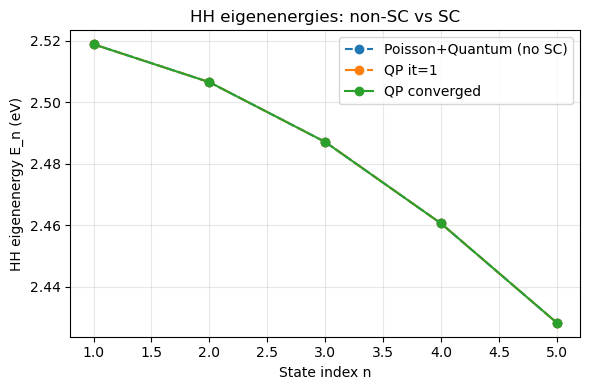

In [42]:
# Compare HH eigenenergies (E1..En) across:
#  - Poisson+Quantum (no SC)
#  - Quantum-Poisson iterations=1
#  - Quantum-Poisson converged

RUN_FULL = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D")
RUN_IT1  = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_it1")
RUN_PQ   = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_poisson_quantum_0")

BIAS = "bias_00000"
N_STATES = 5

def read_probs(run_root: Path) -> pd.DataFrame:
    f = run_root / BIAS / "Quantum" / "c-Ge_QW" / "HH" / "probabilities_shift_k00000.dat"
    return pd.read_csv(f, delim_whitespace=True, comment="#")

def extract_energies(df: pd.DataFrame, n: int) -> np.ndarray:
    cols = [f"E_{i}[eV]" for i in range(1, n+1)]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing energy columns: {missing}\nAvailable: {list(df.columns)}")
    # E_i is constant across x; take first row
    return df.loc[0, cols].to_numpy(dtype=float)

E_full = extract_energies(read_probs(RUN_FULL), N_STATES)
E_it1  = extract_energies(read_probs(RUN_IT1),  N_STATES)
E_pq   = extract_energies(read_probs(RUN_PQ),   N_STATES)

dfE = pd.DataFrame({
    "state": np.arange(1, N_STATES+1),
    "E_full_QP[eV]": E_full,
    "E_it1_QP[eV]":  E_it1,
    "E_poisson+quantum[eV]": E_pq,
})
dfE["Δ(full-it1) [meV]"] = (dfE["E_full_QP[eV]"] - dfE["E_it1_QP[eV]"]) * 1e3
dfE["Δ(full-PQ)  [meV]"] = (dfE["E_full_QP[eV]"] - dfE["E_poisson+quantum[eV]"]) * 1e3

display(dfE)

# quick visual
plt.figure(figsize=(6,4))
plt.plot(dfE["state"], dfE["E_poisson+quantum[eV]"], marker="o", label="Poisson+Quantum (no SC)", linestyle="--")
plt.plot(dfE["state"], dfE["E_it1_QP[eV]"],          marker="o", label="QP it=1", linestyle="-.")
plt.plot(dfE["state"], dfE["E_full_QP[eV]"],         marker="o", label="QP converged", linestyle="-")
plt.xlabel("State index n")
plt.ylabel("HH eigenenergy E_n (eV)")
plt.title("HH eigenenergies: non-SC vs SC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
RUN_FULL = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D")
RUN_IT1  = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_it1")
RUN_PQ   = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D_poisson_quantum_0")

BIAS = "bias_00000"

# Choose which HH states to compare
STATES = [1, 2, 3]

# Zoom window (optional)
XMIN, XMAX = -25, 10
ZOOM = True

def read_probs(run_root: Path) -> pd.DataFrame:
    f = run_root / BIAS / "Quantum" / "c-Ge_QW" / "HH" / "probabilities_shift_k00000.dat"
    return pd.read_csv(f, delim_whitespace=True, comment="#")

runs = [
    ("Poisson+Quantum (no SC)", RUN_PQ),
    ("QP it=1", RUN_IT1),
    ("QP converged", RUN_FULL),
]

fig = go.Figure()

for label, root in runs:
    df = read_probs(root)
    x = df["x[nm]"]

    if ZOOM:
        m = (x >= XMIN) & (x <= XMAX)
        x_plot = x[m]
    else:
        m = slice(None)
        x_plot = x

    for n in STATES:
        col = f"Psi^2_{n}[nm^-1]"
        if col not in df.columns:
            raise ValueError(f"Missing column {col} in {root}")

        fig.add_trace(go.Scatter(
            x=x_plot,
            y=df.loc[m, col],
            mode="lines",
            name=f"{label} | Psi^2_{n}",
        ))

fig.update_layout(
    title="HH wavefunction probabilities |ψ_n(z)|²: non-SC vs SC (toggle traces via legend)",
    xaxis_title="z (nm)",
    yaxis_title="Psi^2 (nm⁻¹)",
    template="plotly_white",
    height=600,
    legend=dict(itemclick="toggle", itemdoubleclick="toggleothers"),
)

if ZOOM:
    fig.update_xaxes(range=[XMIN, XMAX])

fig.show()

Conclusion:
Since the structure is depleted (carrier densities ~0), the coupled Schrödinger–Poisson loop does not modify the potential; therefore Poisson+Quantum and fully self-consistent Quantum–Poisson produce the same eigenenergies.

### 1.5 PG Pinch-off Voltage (No Fermi-level Pinning)

In [198]:
import sys
from pathlib import Path

REPO_ROOT = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit")
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [199]:
import nextnano_analysis as nna

#### - Run Sweep 0V to -3V steps of 0.2V

In [200]:
inp_path = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_1D.in")

VPG = np.round(np.arange(0.0, -3.0 - 1e-12, -0.2), 10).tolist()

sw = nna.sweep_single_var(
    inp_path,
    var="V_PG",
    values=VPG,
    delete_old_files=True,
    delete_input_files=False,
    overwrite=True,
    show_log=True,
    convergenceCheck=True,
    parallel_limit=1
)

print(sw)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Single_Quantum_Dot_1D_sweep__V_PG/Single_Quantum_Dot_1D__V_PG_0.0_ --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_1D__V_PG_0.0_.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                              

In [210]:
import plotly.graph_objects as go

# scale to units of (1e11 carriers/cm^2)
out = out.copy()
out["p_sheet_GeQW_1e11"] = out["p_sheet_GeQW"] / 1e11

fig = go.Figure(go.Scatter(
    x=out["V_PG"],
    y=out["p_sheet_GeQW_1e11"],
    mode="lines+markers",
    name="Ge QW sheet density"
))

fig.update_layout(
    title="Integrated hole sheet density in Ge QW (region_3) vs V_PG",
    xaxis_title="V_PG (V)",
    yaxis_title=r"Integrated holes (×10¹¹ carriers/cm²)",
    template="plotly_white",
    height=520
)

fig.show()

## 2. 2D Simulation

In [44]:
# Point this to your 2D input file (the one for xz_QD)
INPUT_SINGLE_DOT_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/2d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D.in")

sd_2d = nn.InputFile(str(INPUT_SINGLE_DOT_2D))
sd_2d.execute()

print("2D output folder:", sd_2d.folder_output)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/2d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                                             
Th

### - Simulation Health Check

In [45]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0_2D = RUN_2D / "bias_00000"

def tail(path: Path, n: int = 40) -> str:
    lines = path.read_text(errors="ignore").splitlines()
    return "\n".join(lines[-n:])

print("Run root:", RUN_2D)
print("Bias folder:", BIAS0_2D)
print()

# 1) Did it finish?
job_done = RUN_2D / "job_done.txt"
print("job_done.txt exists:", job_done.exists())
if job_done.exists():
    print(job_done.read_text().strip())
print()

# 2) Summary warnings/errors?
summary = RUN_2D / "summary.log"
print("summary.log exists:", summary.exists())
if summary.exists():
    print("---- summary.log (tail) ----")
    print(tail(summary, 60))
print()

# 3) Convergence trace (if present)
it = BIAS0_2D / "iteration_quantum_poisson.dat"
print("iteration_quantum_poisson.dat exists:", it.exists())
if it.exists():
    print("---- iteration_quantum_poisson.dat (tail) ----")
    print(tail(it, 25))
else:
    print("No iteration file found (ok if quantum_poisson wasn't run, but your 2D file uses it).")

Run root: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D
Bias folder: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D/bias_00000

job_done.txt exists: True
Calculation successfully completed.

summary.log exists: True
---- summary.log (tail) ----
Start time: Tue 2026-02-24, 15:51:31 (+0100)
Setup completed.

Performing bias-independent calculations...

Starting calculation for BIAS POINT = BG  -2.000000 V   PG  -3.000000 V   Source  0.000000 V   Drain  0.000000 V   Body  0.000000 V   
   Solving QUANTUM-POISSON...
   Finished QUANTUM-POISSON.
Completed calculation for BIAS POINT.

End time: Tue 2026-02-24, 15:51:40 (+0100)

Simulation completed.

iteration_quantum_poisson.dat exists: True
---- iteration_quantum_poisson.dat (tail) ----
Iteration 	ExactIteration 	Residual_EDensity[1/cm] 	Residual_HDensity[1/cm] 	Residual_Potential[V]
1 	0 	0.000000e+00 	2.740867e-26 	1.433704e-09


x_QD columns: ['x[nm]', 'Material_index[]']
z_QD columns: ['y[nm]', 'Material_index[]']


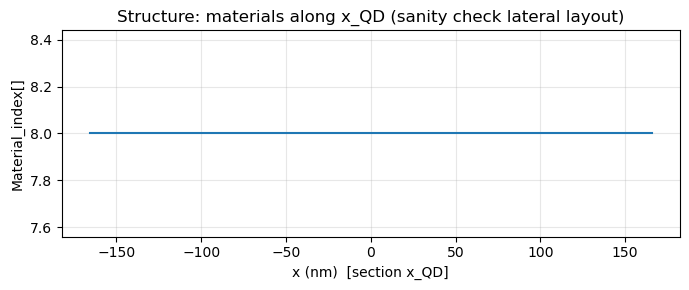

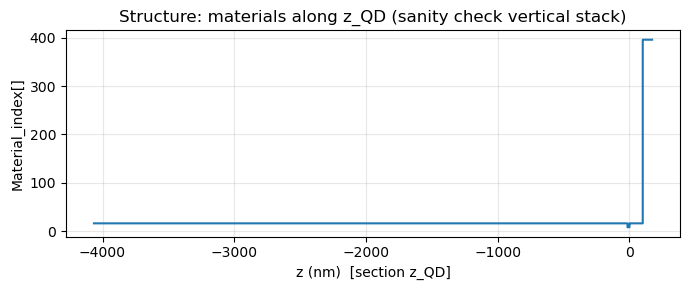

In [47]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
STRUCT = RUN_2D / "Structure"

fx = STRUCT / "materials_1d_x_QD.dat"
fz = STRUCT / "materials_1d_z_QD.dat"

dfx = pd.read_csv(fx, delim_whitespace=True)
dfz = pd.read_csv(fz, delim_whitespace=True)

print("x_QD columns:", dfx.columns.tolist())
print("z_QD columns:", dfz.columns.tolist())

# heuristic: first column is position, second is index/value
xcol_x = dfx.columns[0]
vcol_x = dfx.columns[-1]

xcol_z = dfz.columns[0]
vcol_z = dfz.columns[-1]

plt.figure(figsize=(7,3))
plt.step(dfx[xcol_x], dfx[vcol_x], where="post")
plt.xlabel("x (nm)  [section x_QD]")
plt.ylabel(vcol_x)
plt.title("Structure: materials along x_QD (sanity check lateral layout)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,3))
plt.step(dfz[xcol_z], dfz[vcol_z], where="post")
plt.xlabel("z (nm)  [section z_QD]")
plt.ylabel(vcol_z)
plt.title("Structure: materials along z_QD (sanity check vertical stack)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

x_QD makes sense because the Ohmic contacts (Source and Drain) have a work_function for Al defined instead of a material, so they do not get a material index, and the region is assigned the material index from the previous block which is Ge (wiht index 8 in this simulation).

z_QD also makes sense, since the substrate (SiGe alloy) index is followed by the Ge index, then substrate again, ending with the AlO dielectric. Again here too the plunger gate has a work_function for Al defined instead of a material property.

### - Potential

Potential along x-axis at the depth of the 2DHG (2nm below Ge layer)

Columns: ['x[nm]', 'Potential[V]']


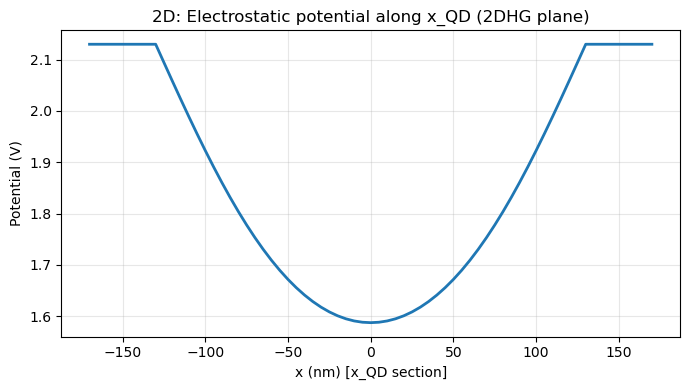

In [48]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0 = RUN_2D / "bias_00000"

df = pd.read_csv(BIAS0 / "potential_1d_x_QD.dat", delim_whitespace=True)
print("Columns:", df.columns.tolist())

xcol = df.columns[0]
vcol = df.columns[-1]

plt.figure(figsize=(7,4))
plt.plot(df[xcol], df[vcol], linewidth=2)
plt.xlabel("x (nm) [x_QD section]")
plt.ylabel("Potential (V)")
plt.title("2D: Electrostatic potential along x_QD (2DHG plane)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Potential along z-axis 

Columns: ['y[nm]', 'Potential[V]']


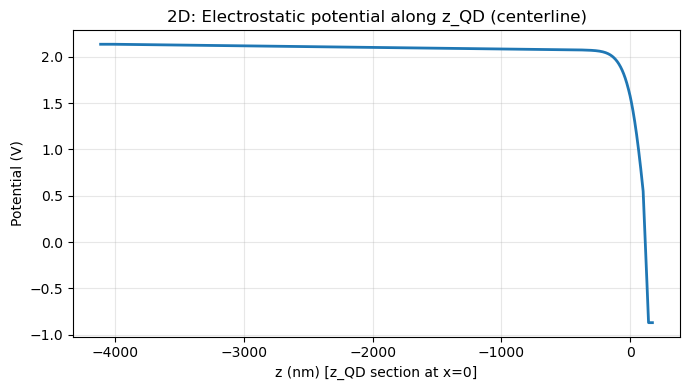

In [52]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0 = RUN_2D / "bias_00000"

df = pd.read_csv(BIAS0 / "potential_1d_z_QD.dat", delim_whitespace=True)
print("Columns:", df.columns.tolist())

zcol = df.columns[0]
vcol = df.columns[-1]

plt.figure(figsize=(7,4))
plt.plot(df[zcol], df[vcol], linewidth=2)
plt.xlabel("z (nm) [z_QD section at x=0]")
plt.ylabel("Potential (V)")
plt.title("2D: Electrostatic potential along z_QD (centerline)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

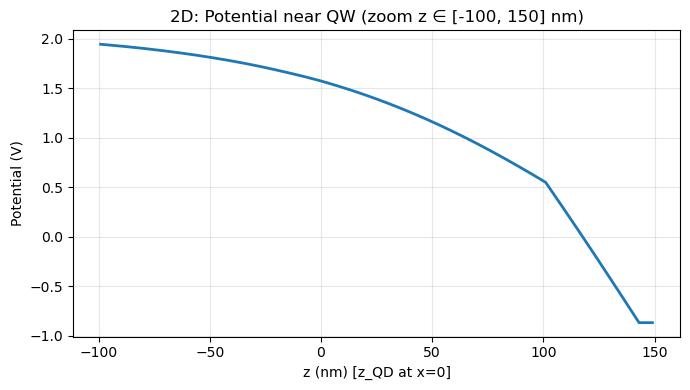

In [69]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0 = RUN_2D / "bias_00000"

df = pd.read_csv(BIAS0 / "potential_1d_z_QD.dat", delim_whitespace=True)
zcol = df.columns[0]
vcol = df.columns[-1]

# Zoom window: around the QW (adjust if needed)
ZMIN, ZMAX = -100, 150
m = (df[zcol] >= ZMIN) & (df[zcol] <= ZMAX)

plt.figure(figsize=(7,4))
plt.plot(df.loc[m, zcol], df.loc[m, vcol], linewidth=2)
plt.xlabel("z (nm) [z_QD at x=0]")
plt.ylabel("Potential (V)")
plt.title(f"2D: Potential near QW (zoom z ∈ [{ZMIN}, {ZMAX}] nm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2D Potential Heatmap

In [174]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0  = RUN_2D / "bias_00000"

x, z, Phi = read_nextnano_fld_rectilinear(BIAS0 / "potential.fld")

fig = go.Figure(data=go.Heatmap(
    x=x, y=z, z=Phi,
    colorbar=dict(title="Potential (V)")
))

fig.update_layout(
    title="potential.fld (electrostatic potential)",
    xaxis_title="x (nm)",
    yaxis_title="z (nm)",
    template="plotly_white",
    height=650,
)

fig.show()

### - Bandedges

HH and LH band edge along x-axis

Columns: ['x[nm]', 'Gamma[eV]', 'Delta_1[eV]', 'Delta_2[eV]', 'Delta_3[eV]', 'L_1[eV]', 'L_2[eV]', 'L_3[eV]', 'L_4[eV]', 'HH[eV]', 'LH[eV]', 'SO[eV]', 'electron_Fermi_level[eV]', 'hole_Fermi_level[eV]']


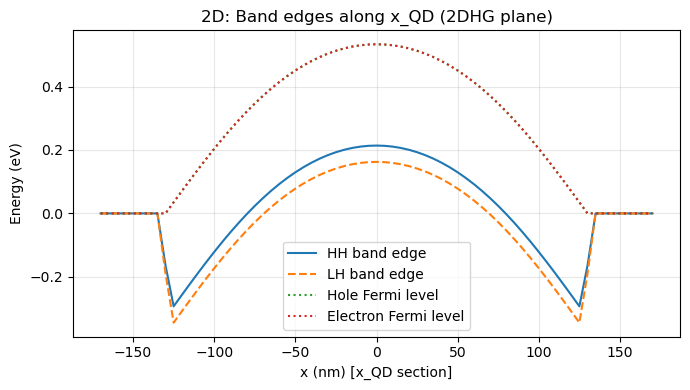

In [49]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0 = RUN_2D / "bias_00000"

df = pd.read_csv(BIAS0 / "bandedges_1d_x_QD.dat", delim_whitespace=True)
print("Columns:", df.columns.tolist())

x = df["x[nm]"]

HH = df["HH[eV]"] if "HH[eV]" in df.columns else None
LH = df["LH[eV]"] if "LH[eV]" in df.columns else None

# Fermi columns sometimes exist; try both
hF = df["hole_Fermi_level[eV]"] if "hole_Fermi_level[eV]" in df.columns else None
eF = df["electron_Fermi_level[eV]"] if "electron_Fermi_level[eV]" in df.columns else None

plt.figure(figsize=(7,4))

if HH is not None:
    plt.plot(x, HH, label="HH band edge")
if LH is not None:
    plt.plot(x, LH, label="LH band edge", linestyle="--")
if hF is not None:
    plt.plot(x, hF, label="Hole Fermi level", linestyle=":")
if eF is not None:
    plt.plot(x, eF, label="Electron Fermi level", linestyle=":")

plt.xlabel("x (nm) [x_QD section]")
plt.ylabel("Energy (eV)")
plt.title("2D: Band edges along x_QD (2DHG plane)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Columns: ['y[nm]', 'Gamma[eV]', 'Delta_1[eV]', 'Delta_2[eV]', 'Delta_3[eV]', 'L_1[eV]', 'L_2[eV]', 'L_3[eV]', 'L_4[eV]', 'HH[eV]', 'LH[eV]', 'SO[eV]', 'electron_Fermi_level[eV]', 'hole_Fermi_level[eV]']


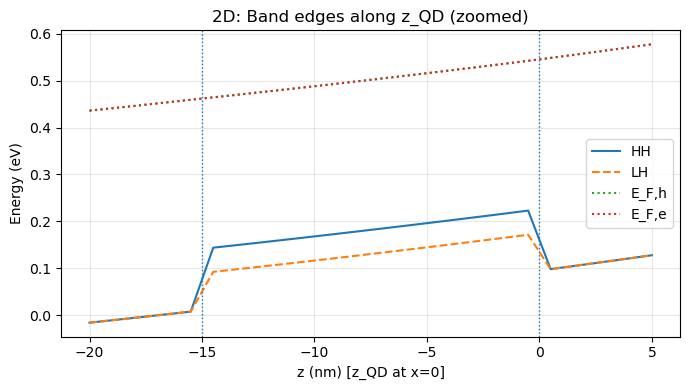

In [91]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0 = RUN_2D / "bias_00000"

df = pd.read_csv(BIAS0 / "bandedges_1d_z_QD.dat", delim_whitespace=True)
print("Columns:", df.columns.tolist())

z = df["y[nm]"] if "y[nm]" in df.columns else df[df.columns[0]]

ZMIN, ZMAX = -20, 5
m = (z >= ZMIN) & (z <= ZMAX)

plt.figure(figsize=(7,4))
plt.plot(z[m], df.loc[m, "HH[eV]"], label="HH")
plt.plot(z[m], df.loc[m, "LH[eV]"], label="LH", linestyle="--")

if "hole_Fermi_level[eV]" in df.columns:
    plt.plot(z[m], df.loc[m, "hole_Fermi_level[eV]"], label="E_F,h", linestyle=":")
if "electron_Fermi_level[eV]" in df.columns:
    plt.plot(z[m], df.loc[m, "electron_Fermi_level[eV]"], label="E_F,e", linestyle=":")

# mark QW boundaries in your convention
plt.axvline(-15, linestyle=":", linewidth=1)
plt.axvline(0, linestyle=":", linewidth=1)

plt.xlabel("z (nm) [z_QD at x=0]")
plt.ylabel("Energy (eV)")
plt.title("2D: Band edges along z_QD (zoomed)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [93]:
import plotly.graph_objects as go
from pathlib import Path

RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0  = RUN_2D / "bias_00000"

x, z, bands = read_nextnano_fld_rectilinear(BIAS0 / "bandedges.fld")
HH = bands[:, :, 8]  # HH

# zoom window around QW/cap
XMIN, XMAX = -150, 150
ZMIN, ZMAX = -20, 5

fig = go.Figure(go.Heatmap(
    x=x, y=z, z=HH,
    colorbar=dict(title="HH (eV)")
))

fig.update_layout(
    title="HH band edge (zoom near QW/cap)",
    xaxis_title="x (nm)",
    yaxis_title="z (nm)",
    template="plotly_white",
    height=650,
)

fig.update_xaxes(range=[XMIN, XMAX])
fig.update_yaxes(range=[ZMIN, ZMAX])

# mark QW boundaries (your convention)
fig.add_hline(y=-15, line_dash="dot")
fig.add_hline(y=0,   line_dash="dot")

fig.show()

In [94]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0  = RUN_2D / "bias_00000"

x, z, bands = read_nextnano_fld_rectilinear(BIAS0 / "bandedges.fld")
HH = bands[:, :, 8]  # HH[eV] is component 9 => index 8 (0-based)

# Choose depths (nm) you want to inspect
z_cuts = [-2.0, -5.0, -10.0, -12.0, -14.0]

fig = go.Figure()

for z0 in z_cuts:
    iz = int(np.argmin(np.abs(z - z0)))
    fig.add_trace(go.Scatter(
        x=x,
        y=HH[iz, :],
        mode="lines",
        name=f"HH(x) at z={z[iz]:.2f} nm"
    ))

fig.update_layout(
    title="HH band edge vs x for several depths inside the QW",
    xaxis_title="x (nm)",
    yaxis_title="HH band edge (eV)",
    template="plotly_white",
    height=520,
    legend=dict(itemclick="toggle", itemdoubleclick="toggleothers"),
)

fig.show()

### - Carrier Density

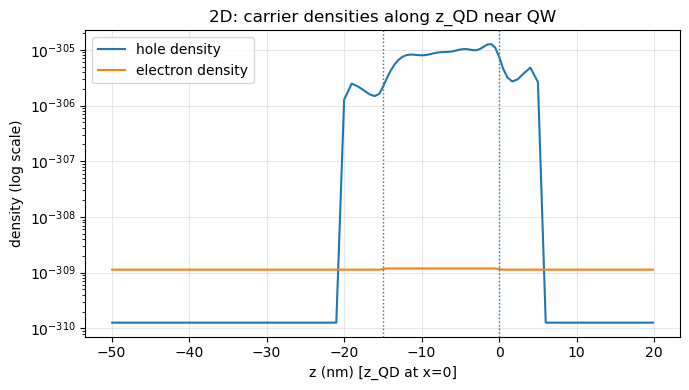

hole density column: Hole_density[1e18_cm^-3]
electron density column: Electron_density[1e18_cm^-3]


In [76]:


RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0 = RUN_2D / "bias_00000"

df_h = pd.read_csv(BIAS0 / "density_hole_1d_z_QD.dat", delim_whitespace=True)
df_e = pd.read_csv(BIAS0 / "density_electron_1d_z_QD.dat", delim_whitespace=True)

zcol_h = df_h.columns[0]
pcol   = df_h.columns[-1]

zcol_e = df_e.columns[0]
ncol   = df_e.columns[-1]

ZMIN, ZMAX = -50, 20  # around QW
mh = (df_h[zcol_h] >= ZMIN) & (df_h[zcol_h] <= ZMAX)
me = (df_e[zcol_e] >= ZMIN) & (df_e[zcol_e] <= ZMAX)

plt.figure(figsize=(7,4))
plt.plot(df_h.loc[mh, zcol_h], df_h.loc[mh, pcol], label="hole density")
plt.plot(df_e.loc[me, zcol_e], df_e.loc[me, ncol], label="electron density")
plt.yscale("log")
plt.axvline(-15, linestyle=":", linewidth=1)
plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("z (nm) [z_QD at x=0]")
plt.ylabel("density (log scale)")
plt.title("2D: carrier densities along z_QD near QW")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("hole density column:", pcol)
print("electron density column:", ncol)

In [83]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0  = RUN_2D / "bias_00000"

x, z, p = read_nextnano_fld_rectilinear(BIAS0 / "density_hole.fld")

# Avoid log(0)
p_pos = np.where(p > 0, p, np.nan)
logp = np.log10(p_pos)

fig = go.Figure(data=go.Heatmap(
    x=x, y=z, z=logp,
    colorbar=dict(title="log10(p)"),
))

fig.update_layout(
    title="density_hole.fld (log10 scale)",
    xaxis_title="x (nm)",
    yaxis_title="z (nm)",
    template="plotly_white",
    height=650,
)

fig.show()

### - Electric Field

In [82]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
BIAS0  = RUN_2D / "bias_00000"

x, z, Enorm = read_nextnano_fld_rectilinear(BIAS0 / "electric_field_norm.fld")

fig = go.Figure(data=go.Heatmap(
    x=x, y=z, z=Enorm,
    colorbar=dict(title="E_norm (kV/cm)")
))

fig.update_layout(
    title="electric_field_norm.fld (|E| in kV/cm)",
    xaxis_title="x (nm)",
    yaxis_title="z (nm)",
    template="plotly_white",
    height=650,
)

fig.show()

### - Quantum density (HH bandedge)

In [109]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path

RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
QROOT  = RUN_2D / "bias_00000" / "Quantum" / "c-Ge_QW"

# Find HH density.fld robustly
hh_density_candidates = list(QROOT.rglob("HH/density.fld"))
if not hh_density_candidates:
    raise FileNotFoundError(f"Could not find HH/density.fld under {QROOT}")
hh_density = hh_density_candidates[0]
print("Using:", hh_density)

x, z, rho = read_nextnano_fld_rectilinear(hh_density)

# log scale for visibility
rho_pos = np.where(rho > 0, rho, np.nan)
logrho = np.log10(rho_pos)

# zoom bounds (quantum region)
ZMIN, ZMAX = -20, 5

fig = go.Figure(go.Heatmap(
    x=x, y=z, z=logrho,
    colorbar=dict(title="log10(HH quantum density)")
))

fig.update_layout(
    title="Quantum HH density (density.fld) — log10 scale (zoomed to quantum region)",
    xaxis_title="x (nm)",
    yaxis_title="z (nm)",
    template="plotly_white",
    height=650,
)

fig.update_yaxes(range=[ZMIN, ZMAX])

fig.show()

Using: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D/bias_00000/Quantum/c-Ge_QW/HH/density.fld


### - Bound States (Energies and Probabilities)

In [106]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
QROOT  = RUN_2D / "bias_00000" / "Quantum" / "c-Ge_QW"

prob_candidates = list(QROOT.rglob("HH/probabilities_shift_k00000.fld"))
if not prob_candidates:
    raise FileNotFoundError(f"Could not find HH/probabilities_shift_k00000.fld under {QROOT}")
prob_fld = prob_candidates[0]
print("Using:", prob_fld)

# --- inspect header labels and veclen ---
header_lines = []
with open(prob_fld, "r", errors="ignore") as f:
    for _ in range(250):
        line = f.readline()
        if not line:
            break
        header_lines.append(line.rstrip())
header = "\n".join(header_lines)

m = re.search(r"^veclen\s*=\s*(\d+)\s*$", header, flags=re.MULTILINE)
veclen = int(m.group(1)) if m else None
labels = re.findall(r'label\s*=\s*"(.*?)"', header)

print("veclen =", veclen)
if labels:
    print("Labels (0-based indices):")
    for i, lab in enumerate(labels):
        print(f"  [{i}] {lab}")
else:
    print("No labels found; we'll plot component 0 by default.")

# --- load the full array ---
x, z, P = read_nextnano_fld_rectilinear(prob_fld)

# Pick which component to plot:
# If labels exist, prefer Psi^2_1... otherwise use index 0.
target_label = "Psi^2_1"
comp = 0
if labels:
    hits = [i for i, lab in enumerate(labels) if "Psi^2_1" in lab]
    if hits:
        comp = hits[0]
    else:
        # fall back to first Psi^2 component if naming differs
        hits2 = [i for i, lab in enumerate(labels) if "Psi^2" in lab]
        comp = hits2[0] if hits2 else 0

Z = P[:, :, comp]

fig = go.Figure(go.Heatmap(
    x=x, y=z, z=Z,
    colorbar=dict(title=labels[comp] if labels else f"component {comp}")
))

fig.update_layout(
    title=f"HH probabilities_shift_k00000.fld — {labels[comp] if labels else f'component {comp}'}",
    xaxis_title="x (nm)",
    yaxis_title="z (nm)",
    template="plotly_white",
    height=650,
)

fig.show()

Using: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D/bias_00000/Quantum/c-Ge_QW/HH/probabilities_shift_k00000.fld
veclen = 100
No labels found; we'll plot component 0 by default.


In [126]:
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

def plot_prob_1d_mixed_y(path: Path, n_states: int = 5, title: str = "", xlim=None, show: bool = True):
    """
    Plot energies E_n (horizontal lines) and probabilities Psi^2_n (curves)
    on the SAME y-axis (mixed units), with no rescaling.

    Supports Psi^2 columns named like: Psi^2_1[nm^-2] (your case).
    Set show=False if you want to build the figure without displaying it.
    """
    df = pd.read_csv(path, delim_whitespace=True, comment="#")
    pos_col = df.columns[0]
    pos = df[pos_col]

    # detect the Psi^2 unit (nm^-2 vs nm^-1 etc.) and build column names robustly
    def psi2_col(i: int) -> str:
        # common variants
        candidates = [
            f"Psi^2_{i}[nm^-2]",
            f"Psi^2_{i}[nm^-1]",
            f"Psi^2_{i}",
        ]
        for c in candidates:
            if c in df.columns:
                return c
        # fallback: find any column containing Psi^2_i
        hits = [c for c in df.columns if f"Psi^2_{i}" in c]
        if hits:
            return hits[0]
        raise KeyError(f"Could not find Psi^2 column for state {i}. Available columns: {df.columns.tolist()}")

    fig = go.Figure()

    # Energies as horizontal lines
    for i in range(1, n_states + 1):
        ecol = f"E_{i}[eV]"
        if ecol in df.columns:
            E = float(df.loc[0, ecol])
            fig.add_trace(go.Scatter(
                x=[pos.min(), pos.max()],
                y=[E, E],
                mode="lines",
                name=f"E{i} (eV)",
                line=dict(dash="dot")
            ))

    # Probabilities
    for i in range(1, n_states + 1):
        pcol = psi2_col(i)
        fig.add_trace(go.Scatter(
            x=pos,
            y=df[pcol],
            mode="lines",
            name=f"{pcol}"
        ))

    fig.update_layout(
        title=title or f"{path.name} (mixed units: E in eV, Psi^2 in nm^-2)",
        xaxis_title=pos_col,
        yaxis_title="Mixed units (E in eV, Psi^2 in nm^-2)",
        template="plotly_white",
        height=600,
        legend=dict(itemclick="toggle", itemdoubleclick="toggleothers"),
    )

    if xlim is not None:
        fig.update_xaxes(range=[xlim[0], xlim[1]])

    fig.show()

In [212]:
plot_prob_1d_mixed_y(
    Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D/bias_00000/Quantum/c-Ge_QW/HH/probabilities_shift_k00000_1d_x_QD.dat"),
    n_states=50,
    title="HH: x_QD cut"
)

In [213]:
plot_prob_1d_mixed_y(
    Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D/bias_00000/Quantum/c-Ge_QW/HH/probabilities_shift_k00000_1d_z_QD.dat"),
    n_states=50,
    title="HH: z_QD cut"
)

In [142]:
from pathlib import Path
import re
import numpy as np
import plotly.graph_objects as go

def _fld_parse_header(path: Path, max_lines: int = 800):
    lines = path.read_text(errors="ignore").splitlines()
    header = "\n".join(lines[:max_lines])

    def get_int(key):
        m = re.search(rf"^{key}\s*=\s*(\d+)\s*$", header, flags=re.MULTILINE)
        if not m:
            raise ValueError(f"Missing '{key} = ...' in header")
        return int(m.group(1))

    ndim  = get_int("ndim")
    nx    = get_int("dim1")
    nz    = get_int("dim2")
    veclen = get_int("veclen")

    labels = re.findall(r'^label\s*=\s*(.+)\s*$', header, flags=re.MULTILINE)

    def get_skip(kind, idx):
        m = re.search(rf"^{kind}\s+{idx}\s+.*?\bskip=(\d+)\b", header, flags=re.MULTILINE)
        if not m:
            raise ValueError(f"Missing '{kind} {idx} ... skip=' in header")
        return int(m.group(1))

    skip_x = get_skip("coord", 1)
    skip_z = get_skip("coord", 2)

    var_skips = {}
    for i in range(1, veclen + 1):
        m = re.search(rf"^variable\s+{i}\s+.*?\bskip=(\d+)\b", header, flags=re.MULTILINE)
        if not m:
            raise ValueError(f"Missing 'variable {i} ... skip=' in header")
        var_skips[i] = int(m.group(1))

    return {
        "lines": lines,
        "ndim": ndim,
        "nx": nx,
        "nz": nz,
        "veclen": veclen,
        "labels": labels,
        "skip_x": skip_x,
        "skip_z": skip_z,
        "var_skips": var_skips,
    }

def _fld_read_floats(lines, start_line, count):
    vals = []
    i = start_line
    while i < len(lines) and len(vals) < count:
        s = lines[i].strip()
        if s and not s.startswith("#"):
            vals.extend([float(v) for v in s.split()])
        i += 1
    if len(vals) < count:
        raise ValueError(f"Expected {count} floats from line {start_line}, got {len(vals)}")
    return np.array(vals[:count], dtype=float)

def _fld_load_variable(path: Path, var_index: int):
    meta = _fld_parse_header(path)
    if meta["ndim"] != 2:
        raise ValueError(f"Expected ndim=2, got {meta['ndim']}")

    lines = meta["lines"]
    nx, nz = meta["nx"], meta["nz"]

    x = _fld_read_floats(lines, meta["skip_x"], nx)
    z = _fld_read_floats(lines, meta["skip_z"], nz)

    skip = meta["var_skips"][var_index]
    data = _fld_read_floats(lines, skip, nx * nz).reshape((nz, nx))  # [z, x]

    label = meta["labels"][var_index - 1] if meta["labels"] else f"variable {var_index}"
    return x, z, data, label

def plot_prob2d_from_fld(fld_path: Path, state: int = 1, zlim=None, xlim=None, log10=False):
    """
    For probabilities_shift_k00000.fld (veclen=100):
      variable n        = E_n[eV]
      variable 50 + n   = Psi^2_n[nm^-2]
    Plots Psi^2_n(x,z) as a 2D heatmap and returns E_n.
    """
    fld_path = Path(fld_path)
    if not fld_path.exists():
        raise FileNotFoundError(f"File not found: {fld_path}")

    if not (1 <= state <= 50):
        raise ValueError("state must be in 1..50")

    # Energy (stored as a constant field)
    _, _, Efield, _ = _fld_load_variable(fld_path, state)
    En = float(Efield.flat[0])

    # Probability density
    x, z, P, Plab = _fld_load_variable(fld_path, 50 + state)

    Z = P
    if log10:
        Z = np.log10(np.where(Z > 0, Z, np.nan))
        cbar = f"log10({Plab})"
    else:
        cbar = Plab

    fig = go.Figure(go.Heatmap(
        x=x, y=z, z=Z,
        colorbar=dict(title=cbar)
    ))

    fig.update_layout(
        title=f"|ψ_{state}(x,z)|²  ({Plab})   (E{state} = {En:.6g} eV)",
        xaxis_title="x (nm)",
        yaxis_title="z (nm)",
        template="plotly_white",
        height=700
    )

    if xlim is not None:
        fig.update_xaxes(range=[xlim[0], xlim[1]])
    if zlim is not None:
        fig.update_yaxes(range=[zlim[0], zlim[1]])

    fig.show()
    return En

In [185]:
RUN_2D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_2D")
PROB_FLD = RUN_2D / "bias_00000" / "Quantum" / "c-Ge_QW" / "HH" / "probabilities_shift_k00000.fld"

E1 = plot_prob2d_from_fld(PROB_FLD, state=1, zlim=(-20, 5), xlim=(-150, 150), log10=False)
print("E1 =", E1, "eV")

E1 = 0.19257902287654 eV
